<a href="https://www.kaggle.com/code/sonawanelalitsunil/company-purchasing-dataset-ml-98?scriptVersionId=236020893" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/company-purchasing-dataset/spend_analysis_dataset.csv


## Title: Company Purchasing Dataset

#### Description: A dataset containing information on company purchasing behavior, including product categories, purchase amounts, and vendor details. It is useful for analyzing spending patterns and supplier relationships.

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/company-purchasing-dataset/spend_analysis_dataset.csv')

In [3]:
df.head()

,TransactionID,ItemName,Category,Quantity,UnitPrice,TotalCost,PurchaseDate,Supplier,Buyer
0,TXN001,Desk Chair,Furniture,10,113.15,1131.50,2024-04-19,TechMart Inc.,Kelly Joseph
1,TXN002,Stapler,Office Supplies,16,12.62,201.92,2024-07-06,CloudSoft Corp.,Kelly Joseph
2,TXN003,Annual Software License,Software,1,5649.34,5649.34,2024-09-10,TechMart Inc.,Kelly Joseph
3,TXN004,Notepad,Stationery,13,2.92,37.96,2024-01-21,FurniWorks Ltd.,Luis Holland
4,TXN005,Notepad,Stationery,19,1.39,26.41,2024-02-03,TechMart Inc.,Cynthia Jenkins


In [4]:
df.tail()

,TransactionID,ItemName,Category,Quantity,UnitPrice,TotalCost,PurchaseDate,Supplier,Buyer
495,TXN496,Whiteboard,Furniture,19,104.12,1978.28,2024-08-20,QuickDeliver Ltd.,Noah Long
496,TXN497,Laptop,Electronics,5,919.08,4595.40,2024-08-15,OfficeSupplies Co.,Walter Pena
497,TXN498,Notepad,Stationery,3,1.51,4.53,2024-05-12,QuickDeliver Ltd.,Jessica Hodges
498,TXN499,Whiteboard,Furniture,17,162.01,2754.17,2024-03-14,FurniWorks Ltd.,Rebecca Bell
499,TXN500,Stapler,Office Supplies,4,13.64,54.56,2024-03-02,TechMart Inc.,Noah Long


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   TransactionID  500 non-null    object 
 1   ItemName       500 non-null    object 
 2   Category       500 non-null    object 
 3   Quantity       500 non-null    int64  
 4   UnitPrice      500 non-null    float64
 5   TotalCost      500 non-null    float64
 6   PurchaseDate   500 non-null    object 
 7   Supplier       500 non-null    object 
 8   Buyer          500 non-null    object 
dtypes: float64(2), int64(1), object(6)
memory usage: 35.3+ KB


In [6]:
df.describe()

,Quantity,UnitPrice,TotalCost
count,500.000000,500.000000,500.00000
mean,9.640000,854.245100,2481.16106
std,6.168834,2132.890832,3527.35316
min,1.000000,1.060000,1.56000
25%,4.000000,14.380000,145.92750
50%,10.000000,143.595000,918.56000
75%,15.000000,287.925000,3123.56750
max,20.000000,9909.240000,18494.60000


In [7]:
df.isnull().sum()

TransactionID    0
ItemName         0
Category         0
Quantity         0
UnitPrice        0
TotalCost        0
PurchaseDate     0
Supplier         0
Buyer            0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.dtypes

TransactionID     object
ItemName          object
Category          object
Quantity           int64
UnitPrice        float64
TotalCost        float64
PurchaseDate      object
Supplier          object
Buyer             object
dtype: object

In [10]:
df.shape

(500, 9)

In [11]:
df.columns

Index(['TransactionID', 'ItemName', 'Category', 'Quantity', 'UnitPrice',
       'TotalCost', 'PurchaseDate', 'Supplier', 'Buyer'],
      dtype='object')

## Data visualizations

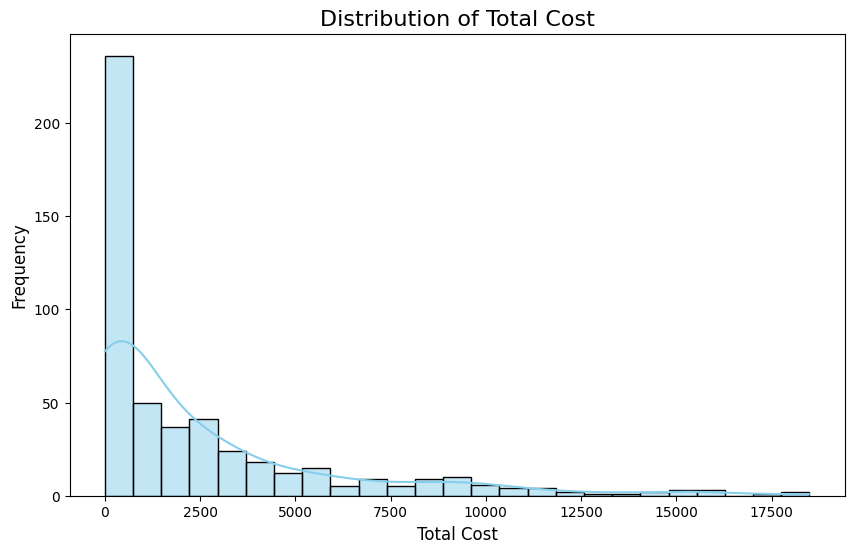

In [12]:
# 1. Distribution of Total Cost
plt.figure(figsize=(10, 6))
sns.histplot(df['TotalCost'], kde=True, color='skyblue')
plt.title('Distribution of Total Cost', fontsize=16)
plt.xlabel('Total Cost', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

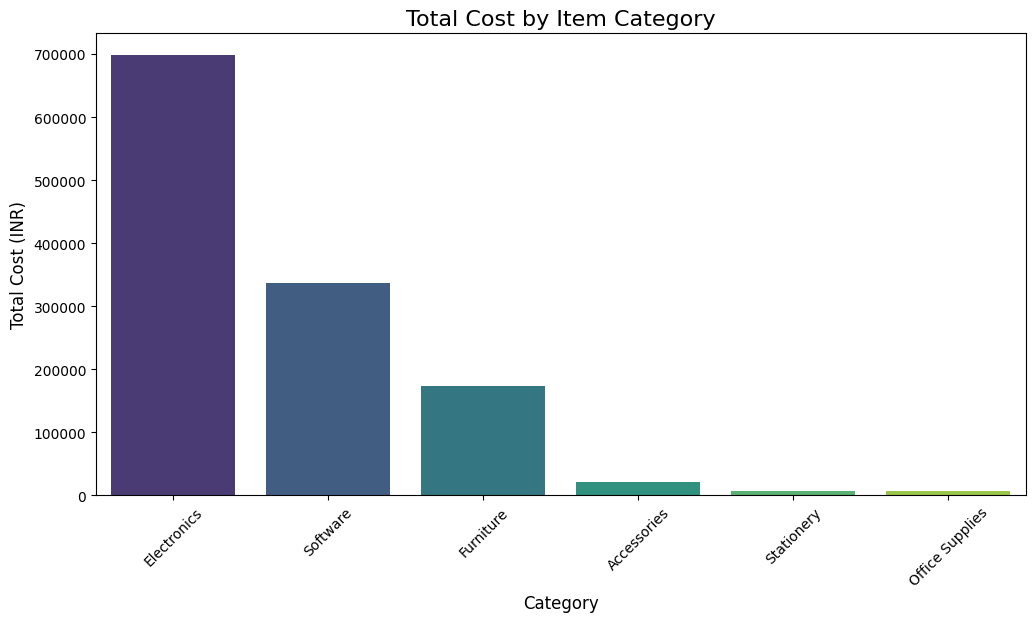

In [13]:
# 2. Total Cost by Item Category
plt.figure(figsize=(12, 6))
category_total = df.groupby('Category')['TotalCost'].sum().sort_values(ascending=False)
sns.barplot(x=category_total.index, y=category_total.values, palette="viridis")
plt.title('Total Cost by Item Category', fontsize=16)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Total Cost (INR)', fontsize=12)
plt.xticks(rotation=45)
plt.show()

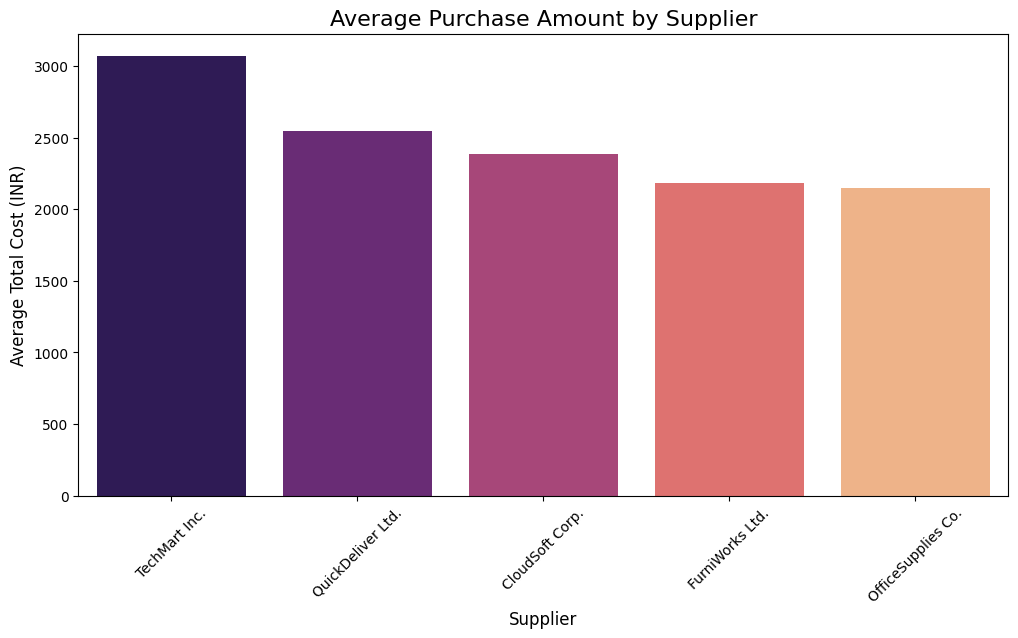

In [14]:
# 3. Average Purchase Amount by Supplier
plt.figure(figsize=(12, 6))
supplier_avg = df.groupby('Supplier')['TotalCost'].mean().sort_values(ascending=False)
sns.barplot(x=supplier_avg.index, y=supplier_avg.values, palette="magma")
plt.title('Average Purchase Amount by Supplier', fontsize=16)
plt.xlabel('Supplier', fontsize=12)
plt.ylabel('Average Total Cost (INR)', fontsize=12)
plt.xticks(rotation=45)
plt.show()


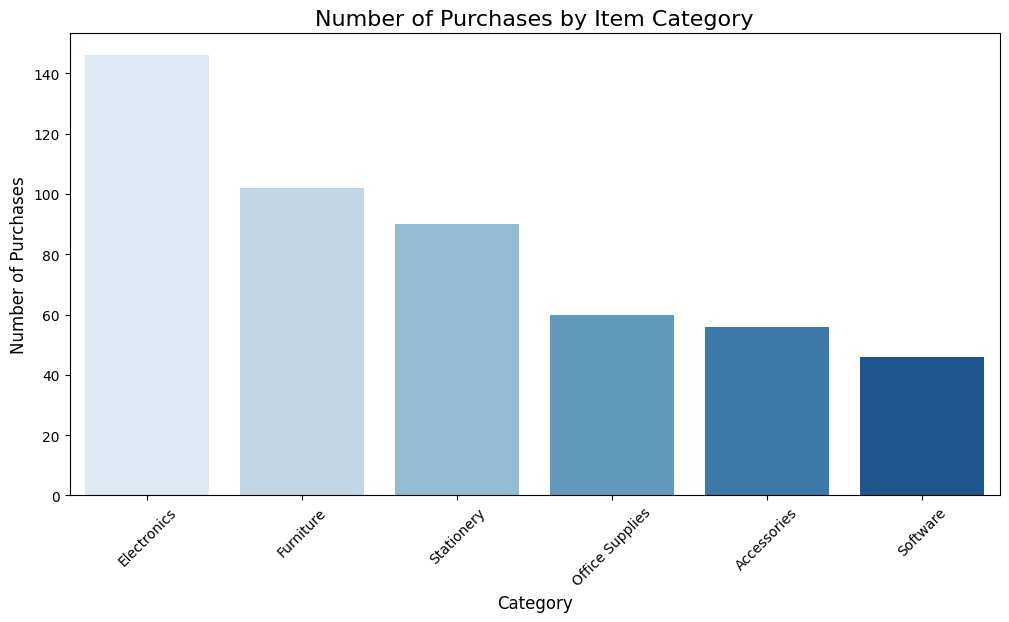

In [15]:
# 4. Number of Purchases by Item Category
plt.figure(figsize=(12, 6))
category_count = df.groupby('Category')['TransactionID'].count().sort_values(ascending=False)
sns.barplot(x=category_count.index, y=category_count.values, palette="Blues")
plt.title('Number of Purchases by Item Category', fontsize=16)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Number of Purchases', fontsize=12)
plt.xticks(rotation=45)
plt.show()

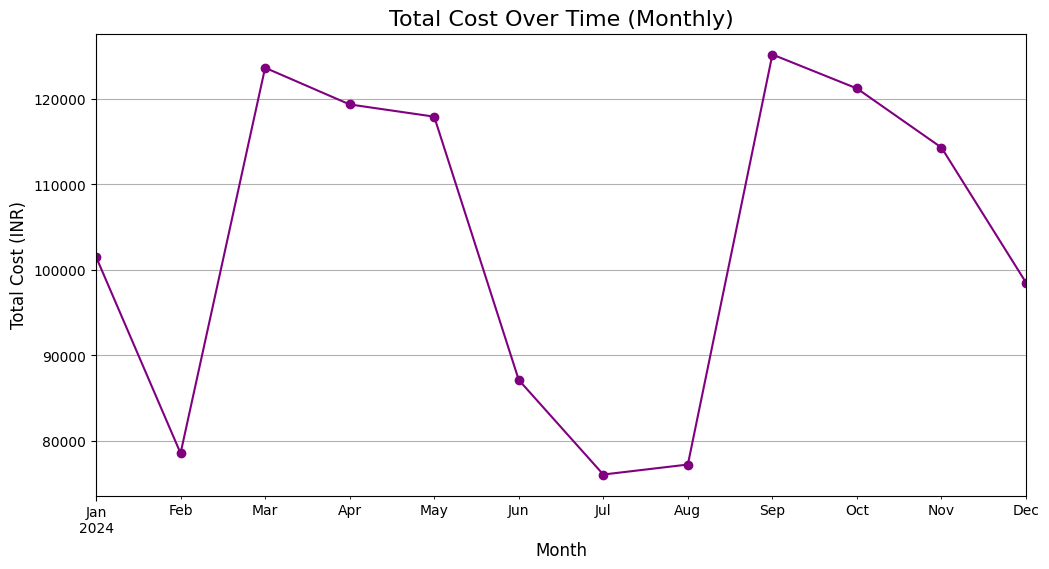

In [16]:
# 5. Total Cost Over Time (Monthly trend)
df['PurchaseDate'] = pd.to_datetime(df['PurchaseDate'])
df['Month'] = df['PurchaseDate'].dt.to_period('M')
monthly_cost = df.groupby('Month')['TotalCost'].sum()
plt.figure(figsize=(12, 6))
monthly_cost.plot(kind='line', color='purple', marker='o')
plt.title('Total Cost Over Time (Monthly)', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Cost (INR)', fontsize=12)
plt.grid(True)
plt.show()


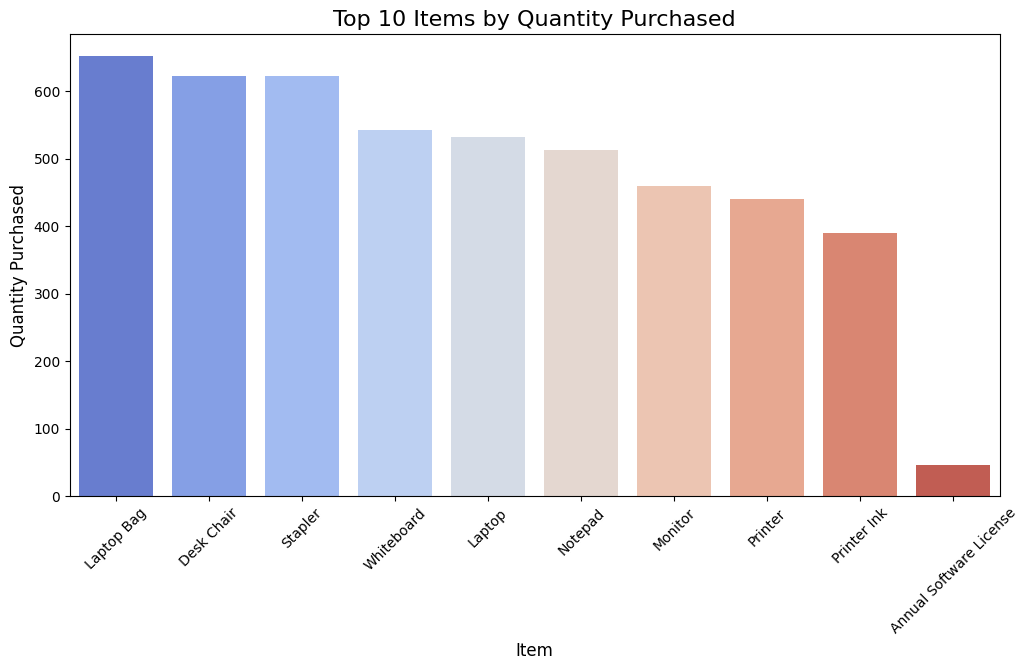

In [17]:
# 6. Total Quantity Purchased by Item
plt.figure(figsize=(12, 6))
item_quantity = df.groupby('ItemName')['Quantity'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=item_quantity.index, y=item_quantity.values, palette="coolwarm")
plt.title('Top 10 Items by Quantity Purchased', fontsize=16)
plt.xlabel('Item', fontsize=12)
plt.ylabel('Quantity Purchased', fontsize=12)
plt.xticks(rotation=45)
plt.show()

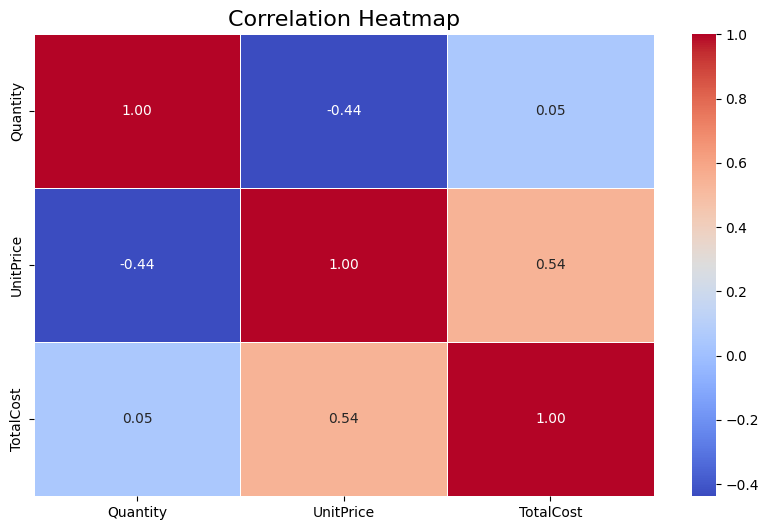

In [18]:
# 7. Correlation Heatmap of Numeric Features
plt.figure(figsize=(10, 6))
correlation = df[['Quantity', 'UnitPrice', 'TotalCost']].corr()
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=16)
plt.show()


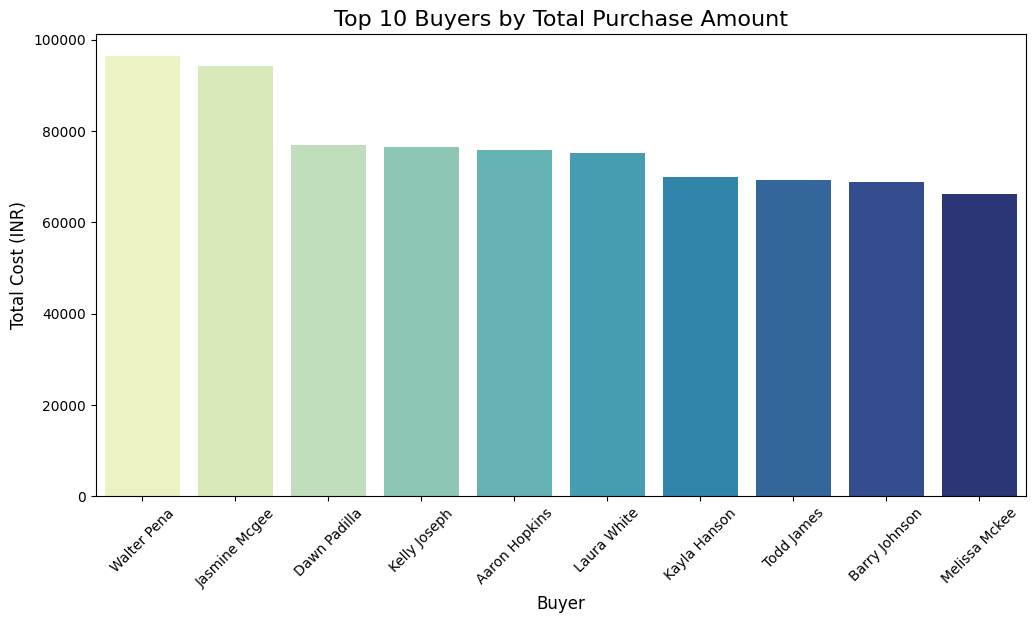

In [19]:
# 8. Total Cost by Buyer
plt.figure(figsize=(12, 6))
buyer_total = df.groupby('Buyer')['TotalCost'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=buyer_total.index, y=buyer_total.values, palette="YlGnBu")
plt.title('Top 10 Buyers by Total Purchase Amount', fontsize=16)
plt.xlabel('Buyer', fontsize=12)
plt.ylabel('Total Cost (INR)', fontsize=12)
plt.xticks(rotation=45)
plt.show()

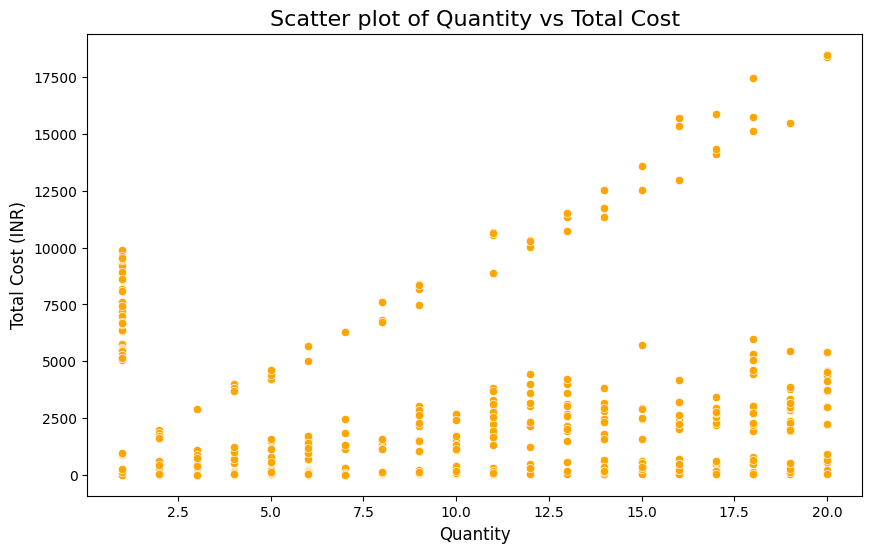

In [20]:
# 9. Scatter plot between Quantity and Total Cost
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['Quantity'], y=df['TotalCost'], color='orange')
plt.title('Scatter plot of Quantity vs Total Cost', fontsize=16)
plt.xlabel('Quantity', fontsize=12)
plt.ylabel('Total Cost (INR)', fontsize=12)
plt.show()

## Predictive modeling

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [22]:
df['HighCost'] = np.where(df['TotalCost'] > 5000, 'High', 'Low')

In [23]:
label_encoder = LabelEncoder()

# Encode categorical columns (Supplier, Category, ItemName, Buyer)
df['Supplier'] = label_encoder.fit_transform(df['Supplier'])
df['Category'] = label_encoder.fit_transform(df['Category'])
df['ItemName'] = label_encoder.fit_transform(df['ItemName'])
df['Buyer'] = label_encoder.fit_transform(df['Buyer'])
df['HighCost'] = label_encoder.fit_transform(df['HighCost'])

In [24]:
X = df[['Supplier', 'Category', 'ItemName', 'Quantity', 'UnitPrice', 'Buyer']]
y = df['HighCost']

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
# Step 5: Define and train the models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Support Vector Machine': SVC(),
    'Naive Bayes': GaussianNB()
}

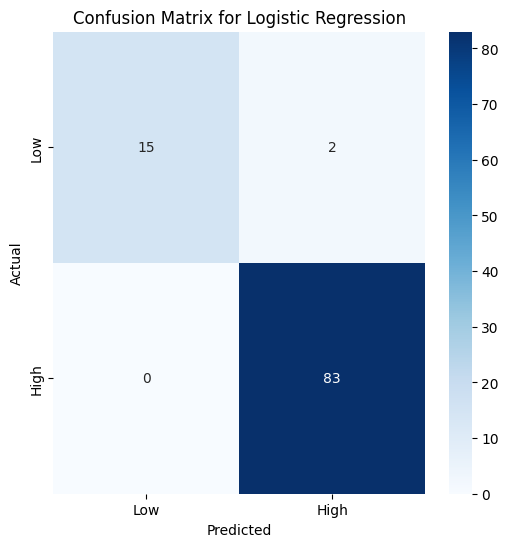

Classification Report for Logistic Regression:

              precision    recall  f1-score   support

           0       1.00      0.88      0.94        17
           1       0.98      1.00      0.99        83

    accuracy                           0.98       100
   macro avg       0.99      0.94      0.96       100
weighted avg       0.98      0.98      0.98       100



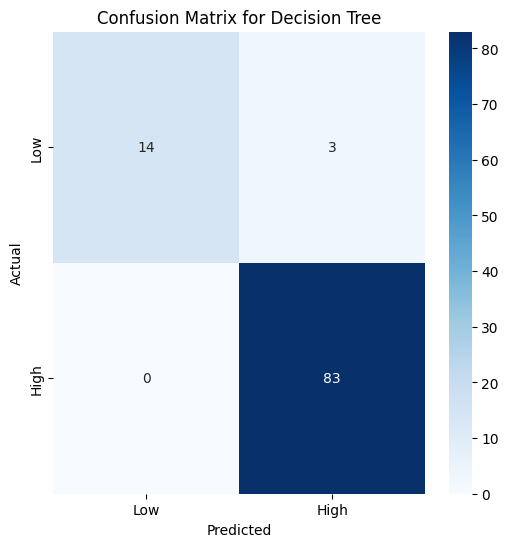

Classification Report for Decision Tree:

              precision    recall  f1-score   support

           0       1.00      0.82      0.90        17
           1       0.97      1.00      0.98        83

    accuracy                           0.97       100
   macro avg       0.98      0.91      0.94       100
weighted avg       0.97      0.97      0.97       100



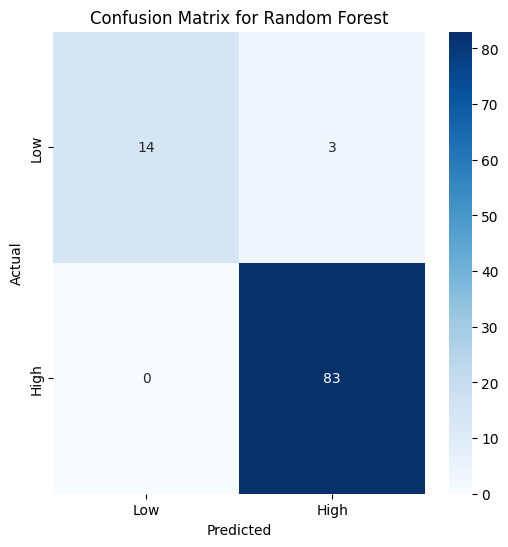

Classification Report for Random Forest:

              precision    recall  f1-score   support

           0       1.00      0.82      0.90        17
           1       0.97      1.00      0.98        83

    accuracy                           0.97       100
   macro avg       0.98      0.91      0.94       100
weighted avg       0.97      0.97      0.97       100



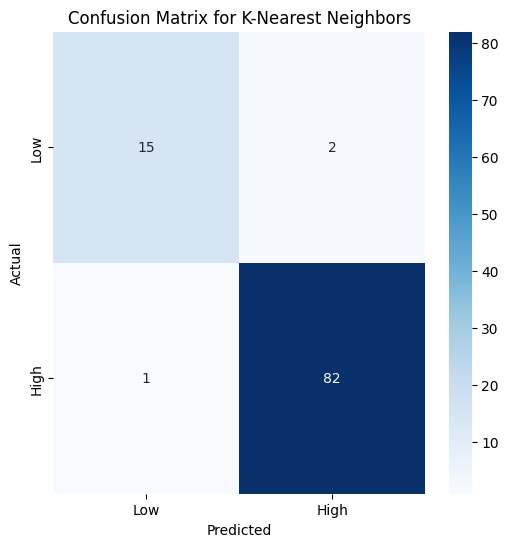

Classification Report for K-Nearest Neighbors:

              precision    recall  f1-score   support

           0       0.94      0.88      0.91        17
           1       0.98      0.99      0.98        83

    accuracy                           0.97       100
   macro avg       0.96      0.94      0.95       100
weighted avg       0.97      0.97      0.97       100



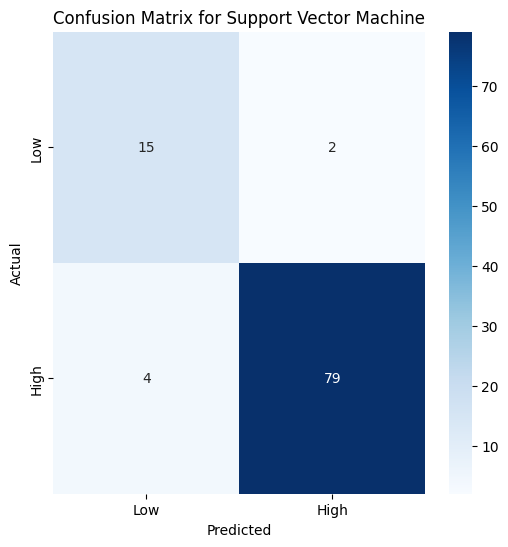

Classification Report for Support Vector Machine:

              precision    recall  f1-score   support

           0       0.79      0.88      0.83        17
           1       0.98      0.95      0.96        83

    accuracy                           0.94       100
   macro avg       0.88      0.92      0.90       100
weighted avg       0.94      0.94      0.94       100



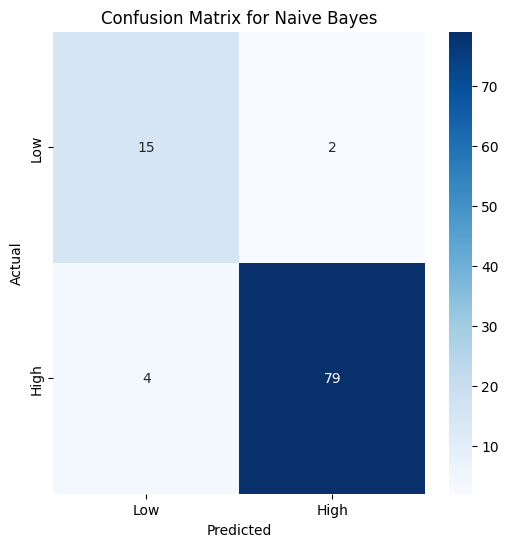

Classification Report for Naive Bayes:

              precision    recall  f1-score   support

           0       0.79      0.88      0.83        17
           1       0.98      0.95      0.96        83

    accuracy                           0.94       100
   macro avg       0.88      0.92      0.90       100
weighted avg       0.94      0.94      0.94       100



In [27]:
# Step 6: Evaluate each model
results = {}

for model_name, model in models.items():
    # Fit the model
    model.fit(X_train, y_train)
    
    # Predict the test set
    y_pred = model.predict(X_test)
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    
    # Classification report (Precision, Recall, F1-Score)
    cr = classification_report(y_test, y_pred, output_dict=True)
    
    # Store results
    results[model_name] = {'Confusion Matrix': cm, 'Classification Report': cr}
    
    # Display confusion matrix
    plt.figure(figsize=(6, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Low', 'High'], yticklabels=['Low', 'High'])
    plt.title(f'Confusion Matrix for {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    
    # Display classification report
    print(f"Classification Report for {model_name}:\n")
    print(classification_report(y_test, y_pred))


In [28]:
for model_name, model_results in results.items():
    print(f"Results for {model_name}:\n")
    print("Confusion Matrix:\n", model_results['Confusion Matrix'])
    print("Classification Report:\n", model_results['Classification Report'])
    print("\n" + "-"*50 + "\n")

Results for Logistic Regression:

Confusion Matrix:
 [[15  2]
 [ 0 83]]
Classification Report:
 {'0': {'precision': 1.0, 'recall': 0.8823529411764706, 'f1-score': 0.9375, 'support': 17}, '1': {'precision': 0.9764705882352941, 'recall': 1.0, 'f1-score': 0.988095238095238, 'support': 83}, 'accuracy': 0.98, 'macro avg': {'precision': 0.9882352941176471, 'recall': 0.9411764705882353, 'f1-score': 0.9627976190476191, 'support': 100}, 'weighted avg': {'precision': 0.9804705882352941, 'recall': 0.98, 'f1-score': 0.9794940476190476, 'support': 100}}

--------------------------------------------------

Results for Decision Tree:

Confusion Matrix:
 [[14  3]
 [ 0 83]]
Classification Report:
 {'0': {'precision': 1.0, 'recall': 0.8235294117647058, 'f1-score': 0.9032258064516129, 'support': 17}, '1': {'precision': 0.9651162790697675, 'recall': 1.0, 'f1-score': 0.9822485207100593, 'support': 83}, 'accuracy': 0.97, 'macro avg': {'precision': 0.9825581395348837, 'recall': 0.9117647058823529, 'f1-score'

## Thank you..pls upvote!!!